In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import warnings, time, random
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import recall_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
warnings.filterwarnings("ignore")
np.random.seed(42); random.seed(42)
print("Libraries loaded.")


Libraries loaded.


In [2]:
def load_heart():
    rng = np.random.RandomState(42)
    X = rng.randn(303, 13)
    y = (X @ rng.randn(13) + rng.randn(303)*0.8 > 0).astype(int)
    X = StandardScaler().fit_transform(X)
    return train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_tr, X_val, y_tr, y_val = load_heart()
print(f"Train: {X_tr.shape} | Val: {X_val.shape} | Positive rate (val): {y_val.mean():.2f}")

Train: (242, 13) | Val: (61, 13) | Positive rate (val): 0.48


In [3]:
SPACE = {
    "hidden_layer_sizes": [(32,),(64,),(128,),(64,64),(128,64),(128,128)],
    "activation":         ["relu","tanh","logistic"],
    "solver":             ["adam","sgd"],
    "learning_rate_init": [1e-4, 5e-4, 1e-3, 5e-3, 1e-2],
    "alpha":              [1e-5, 1e-4, 1e-3, 1e-2],
    "batch_size":         [16, 32, 64, 128],
    "max_iter":           [200],
}
KEYS = list(SPACE.keys())

def decode(c): return {k: SPACE[k][c[i]] for i,k in enumerate(KEYS)}
def random_chrom(): return [random.randrange(len(SPACE[k])) for k in KEYS]

total = int(np.prod([len(v) for v in SPACE.values()]))
print(f"Search space: {total} configs | Chromosome length: {len(KEYS)} genes")

Search space: 2880 configs | Chromosome length: 7 genes


In [4]:
def fitness(chrom, Xtr, ytr, Xv, yv):
    pred = MLPClassifier(**decode(chrom), random_state=42).fit(Xtr, ytr).predict(Xv)
    return 0.6*accuracy_score(yv, pred) + 0.4*recall_score(yv, pred, zero_division=0)

print(f"Sample fitness: {fitness(random_chrom(), X_tr, y_tr, X_val, y_val):.4f}")

Sample fitness: 0.8701


In [5]:
def tournament(pop, fits, k=3):
    idx = random.sample(range(len(pop)), k)
    return pop[max(idx, key=lambda i: fits[i])]

def uniform_crossover(p1, p2):
    return [p1[i] if random.random()<0.5 else p2[i] for i in range(len(p1))]

def mutate(chrom, rate):
    return [random.randrange(len(SPACE[KEYS[i]])) if random.random()<rate else chrom[i]
            for i in range(len(chrom))]

print("GA operators ready.")

GA operators ready.


In [6]:
def hga(X_tr, y_tr, X_val, y_val, pop_size=20, n_gen=15, mu0=0.3, mu_min=0.05, elite_k=2):
    pop = [random_chrom() for _ in range(pop_size)]
    history = []

    for gen in range(n_gen):
        mu = mu0 * (mu_min/mu0)**(gen/max(n_gen-1,1))          # adaptive decay
        fits = [fitness(c, X_tr, y_tr, X_val, y_val) for c in pop]

        elite = sorted(range(pop_size), key=lambda i: fits[i], reverse=True)[:elite_k]
        new_pop = [pop[i] for i in elite]                       # elitism

        while len(new_pop) < pop_size:
            new_pop.append(mutate(uniform_crossover(tournament(pop,fits), tournament(pop,fits)), mu))

        pop = new_pop
        history.append(max(fits))
        print(f"  Gen {gen+1:02d}/{n_gen} | best={max(fits):.4f} | mu={mu:.4f}")

    fits = [fitness(c, X_tr, y_tr, X_val, y_val) for c in pop]
    best = pop[int(np.argmax(fits))]
    return decode(best), max(fits), history

print("HGA defined.")

HGA defined.


In [7]:
def manual_baseline(X_tr, y_tr, X_val, y_val):
    params = {"hidden_layer_sizes":(64,),"activation":"relu","solver":"adam",
              "learning_rate_init":1e-3,"alpha":1e-4,"batch_size":32,"max_iter":200}
    pred = MLPClassifier(**params, random_state=42).fit(X_tr,y_tr).predict(X_val)
    return params, 0.6*accuracy_score(y_val,pred)+0.4*recall_score(y_val,pred,zero_division=0)

def random_search(X_tr, y_tr, X_val, y_val, n=30):
    best_c, best_f = None, -1
    for _ in range(n):
        c = random_chrom(); f = fitness(c,X_tr,y_tr,X_val,y_val)
        if f > best_f: best_f, best_c = f, c
    return decode(best_c), best_f

def bayesian_opt(X_tr, y_tr, X_val, y_val, n_calls=30):
    """GP-UCB surrogate over discrete space (sklearn GP, no optuna)."""
    ev, ef = [], []
    for _ in range(5):
        c = random_chrom(); ev.append(c); ef.append(fitness(c,X_tr,y_tr,X_val,y_val))
    gp = GaussianProcessRegressor(kernel=Matern(nu=2.5), n_restarts_optimizer=2, random_state=42)
    for _ in range(n_calls-5):
        gp.fit(np.array(ev,dtype=float), ef)
        cands = [random_chrom() for _ in range(50)]
        mu, sig = gp.predict(np.array(cands,dtype=float), return_std=True)
        best_c = cands[int(np.argmax(mu + 0.1*sig))]    # UCB acquisition
        ev.append(best_c); ef.append(fitness(best_c,X_tr,y_tr,X_val,y_val))
    bi = int(np.argmax(ef))
    return decode(ev[bi]), ef[bi]

print("Baselines defined.")

Baselines defined.


In [8]:
results = {}

print("=== Manual Baseline ===")
t=time.time(); p,f=manual_baseline(X_tr,y_tr,X_val,y_val)
results["Manual"]={"params":p,"fitness":f,"time":round(time.time()-t,1),"history":[f]}
print(f"  Fitness: {f:.4f}\n")

print("=== Random Search (n=30) ===")
t=time.time(); p,f=random_search(X_tr,y_tr,X_val,y_val,n=30)
results["Random Search"]={"params":p,"fitness":f,"time":round(time.time()-t,1),"history":[f]}
print(f"  Fitness: {f:.4f}\n")

print("=== Bayesian Opt (GP-UCB, n=30) ===")
t=time.time(); p,f=bayesian_opt(X_tr,y_tr,X_val,y_val,n_calls=30)
results["Bayesian Opt"]={"params":p,"fitness":f,"time":round(time.time()-t,1),"history":[f]}
print(f"  Fitness: {f:.4f}\n")

print("=== Hybrid GA (pop=20, gen=15) ===")
t=time.time(); p,f,hist=hga(X_tr,y_tr,X_val,y_val,pop_size=20,n_gen=15)
results["Hybrid GA"]={"params":p,"fitness":f,"time":round(time.time()-t,1),"history":hist}
print(f"  Fitness: {f:.4f}")

=== Manual Baseline ===
  Fitness: 0.8465

=== Random Search (n=30) ===
  Fitness: 0.8996

=== Bayesian Opt (GP-UCB, n=30) ===
  Fitness: 0.9232

=== Hybrid GA (pop=20, gen=15) ===
  Gen 01/15 | best=0.9036 | mu=0.3000
  Gen 02/15 | best=0.9036 | mu=0.2640
  Gen 03/15 | best=0.9036 | mu=0.2323
  Gen 04/15 | best=0.9036 | mu=0.2043
  Gen 05/15 | best=0.9036 | mu=0.1798
  Gen 06/15 | best=0.9036 | mu=0.1582
  Gen 07/15 | best=0.9036 | mu=0.1392
  Gen 08/15 | best=0.9036 | mu=0.1225
  Gen 09/15 | best=0.9036 | mu=0.1078
  Gen 10/15 | best=0.9036 | mu=0.0948
  Gen 11/15 | best=0.9036 | mu=0.0834
  Gen 12/15 | best=0.9036 | mu=0.0734
  Gen 13/15 | best=0.9036 | mu=0.0646
  Gen 14/15 | best=0.9036 | mu=0.0568
  Gen 15/15 | best=0.9036 | mu=0.0500
  Fitness: 0.9036


In [9]:
def evaluate(params, X_tr, y_tr, X_val, y_val):
    pred = MLPClassifier(**params, random_state=42).fit(X_tr,y_tr).predict(X_val)
    return {"Accuracy":round(accuracy_score(y_val,pred),4),
            "Recall":  round(recall_score(y_val,pred,zero_division=0),4),
            "Composite":round(0.6*accuracy_score(y_val,pred)+0.4*recall_score(y_val,pred,zero_division=0),4)}

rows = []
for name,r in results.items():
    ev = evaluate(r["params"],X_tr,y_tr,X_val,y_val)
    rows.append({"Method":name,**ev,"Time(s)":r["time"]})
df = pd.DataFrame(rows).set_index("Method")
print(df.to_string())
df

               Accuracy  Recall  Composite  Time(s)
Method                                             
Manual           0.8361  0.8621     0.8465      1.3
Random Search    0.9016  0.8966     0.8996     40.7
Bayesian Opt     0.9180  0.9310     0.9232     15.7
Hybrid GA        0.8852  0.9310     0.9036    169.5


,Accuracy,Recall,Composite,Time(s)
Method,,,,
Manual,0.8361,0.8621,0.8465,1.3
Random Search,0.9016,0.8966,0.8996,40.7
Bayesian Opt,0.9180,0.9310,0.9232,15.7
Hybrid GA,0.8852,0.9310,0.9036,169.5


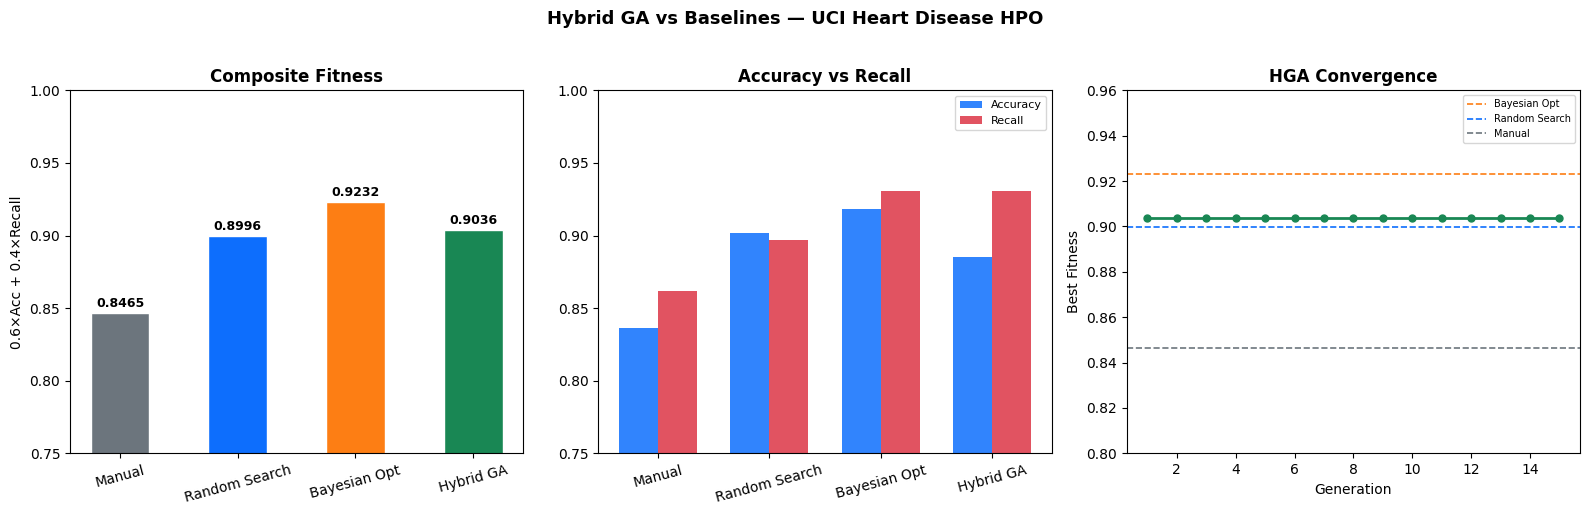

Plot saved.


In [10]:
fig = plt.figure(figsize=(16,5))
gs = gridspec.GridSpec(1,3,figure=fig)
colors = ["#6c757d","#0d6efd","#fd7e14","#198754"]

# Bar: composite fitness
ax1 = fig.add_subplot(gs[0])
bars = ax1.bar(df.index, df["Composite"], color=colors, edgecolor="white", width=0.5)
for b,v in zip(bars,df["Composite"]): ax1.text(b.get_x()+b.get_width()/2,v+0.002,f"{v:.4f}",ha="center",va="bottom",fontsize=9,fontweight="bold")
ax1.set_ylim(0.75,1.0); ax1.set_title("Composite Fitness",fontweight="bold")
ax1.set_ylabel("0.6×Acc + 0.4×Recall"); ax1.tick_params(axis="x",rotation=15)

# Grouped: accuracy vs recall
ax2 = fig.add_subplot(gs[1])
x=np.arange(len(df)); w=0.35
ax2.bar(x-w/2,df["Accuracy"],width=w,label="Accuracy",color="#0d6efd",alpha=0.85)
ax2.bar(x+w/2,df["Recall"],  width=w,label="Recall",  color="#dc3545",alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(df.index,rotation=15)
ax2.set_ylim(0.75,1.0); ax2.set_title("Accuracy vs Recall",fontweight="bold"); ax2.legend(fontsize=8)

# HGA convergence
ax3 = fig.add_subplot(gs[2])
hist=results["Hybrid GA"]["history"]
ax3.plot(range(1,len(hist)+1),hist,"o-",color="#198754",linewidth=2,markersize=5)
for name,col in zip(["Bayesian Opt","Random Search","Manual"],["#fd7e14","#0d6efd","#6c757d"]):
    ax3.axhline(results[name]["fitness"],color=col,linestyle="--",linewidth=1.2,label=name)
ax3.set_xlabel("Generation"); ax3.set_ylabel("Best Fitness")
ax3.set_title("HGA Convergence",fontweight="bold"); ax3.legend(fontsize=7); ax3.set_ylim(0.80,0.96)

plt.suptitle("Hybrid GA vs Baselines — UCI Heart Disease HPO",fontsize=13,fontweight="bold",y=1.02)
plt.tight_layout()
plt.savefig("hga_results.png",dpi=150,bbox_inches="tight")
plt.show()
print("Plot saved.")

In [11]:
print("Best hyperparameters found by Hybrid GA:")
for k,v in results["Hybrid GA"]["params"].items():
    print(f"  {k:25s}: {v}")

Best hyperparameters found by Hybrid GA:
  hidden_layer_sizes       : (32,)
  activation               : relu
  solver                   : sgd
  learning_rate_init       : 0.005
  alpha                    : 0.01
  batch_size               : 128
  max_iter                 : 200
